# Fuzzy Regression Discontinuity — Government Transfers & Political Support

Working through this step by step.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf


In [23]:
df = pd.read_csv("../data/raw/gov_transfers.csv")

print(df.shape)
df.head()


(1948, 5)


,Income_Centered,Education,Age,Participation,Support
0,0.006571,3.5,23.666666,0,1.0
1,0.011075,1.5,42.000000,0,1.0
2,0.002424,4.0,43.000000,0,1.0
3,0.007650,6.0,21.000000,0,0.5
4,0.010001,2.0,33.000000,0,1.0


- Income_Centered — household income minus the eligibility threshold. Negative = below the cutoff = income-eligible for the transfer. This is our forcing variable.
- Education, Age — household averages, useful later for a balance check (same role state_population played last time).
- Participation — did the household actually enroll in the transfer program (0/1). This is the treatment, and notice it's separate from eligibility — that's the fuzzy part.
- Support — measure of political support for the government (looks continuous here, e.g. 1.0, 0.5 — not a strict 0/1, wor

In [24]:
columns = {col: col.lower() for col in df.columns}
df = df.rename(columns=columns)

In [25]:
df

,income_centered,education,age,participation,support
0,0.006571,3.5,23.666666,0,1.0
1,0.011075,1.5,42.000000,0,1.0
2,0.002424,4.0,43.000000,0,1.0
3,0.007650,6.0,21.000000,0,0.5
4,0.010001,2.0,33.000000,0,1.0
...,...,...,...,...,...
1943,-0.013489,2.0,27.333334,1,1.0
1944,-0.012106,4.5,37.000000,1,1.0
1945,-0.010159,5.0,25.857143,1,1.0
1946,-0.008668,3.0,26.000000,1,1.0


In [58]:
df = df[~df['education'].isnull()]

## validate

In [59]:
df.isnull().sum()

income_centered    0
education          0
age                0
participation      0
support            0
threshold          0
dtype: int64

## Visualize

<Axes: >

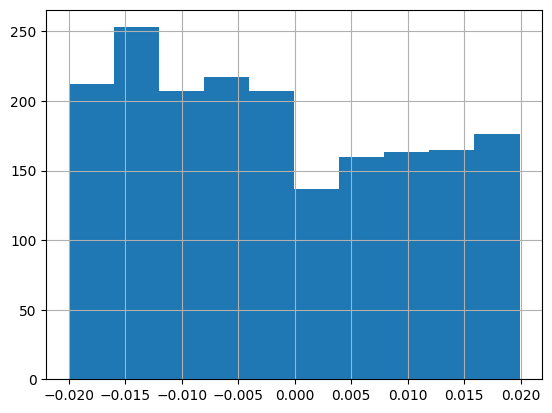

In [42]:
df["income_centered"].hist()

Text(0.5, 1.0, 'Income (Centered at 0)')

<Figure size 800x800 with 0 Axes>

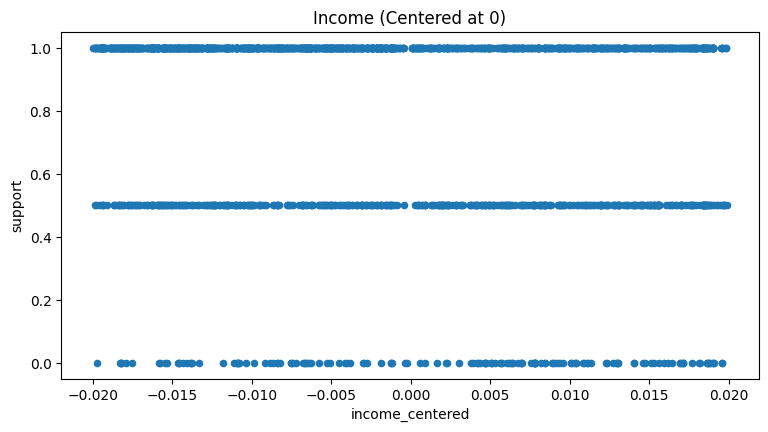

In [43]:
plt.figure(figsize=(8,8))
fig, ax = plt.subplots(figsize=(9, 4.5))
df.plot.scatter(x="income_centered", y="support", ax=ax)
plt.title("Income (Centered at 0)")



In [44]:
from scipy.stats import binomtest



just_below = df[df["income_centered"] < 0]
just_above = df[df["income_centered"] > 0]

n_below = len(just_below)
n_above = len(just_above)
n_total = n_below + n_above

result = binomtest(n_above, n_total, p=0.5)

print(f"Races in [-{window}, 0)  : {n_below}")
print(f"Races in [0, {window})   : {n_above}")
print(f"Total in window         : {n_total}")
print(f"p-value                 : {result.pvalue:.3f}")

Races in [-5, 0)  : 1096
Races in [0, 5)   : 801
Total in window         : 1897
p-value                 : 0.000


In [45]:
result

BinomTestResult(k=801, n=1897, alternative='two-sided', statistic=0.4222456510279389, pvalue=1.3471205795533709e-11)

In [46]:
df

,income_centered,education,age,participation,support
0,0.006571,3.5,23.666666,0,1.0
1,0.011075,1.5,42.000000,0,1.0
2,0.002424,4.0,43.000000,0,1.0
3,0.007650,6.0,21.000000,0,0.5
4,0.010001,2.0,33.000000,0,1.0
...,...,...,...,...,...
1943,-0.013489,2.0,27.333334,1,1.0
1944,-0.012106,4.5,37.000000,1,1.0
1945,-0.010159,5.0,25.857143,1,1.0
1946,-0.008668,3.0,26.000000,1,1.0


In [62]:
df['income_centered'].max(), df['income_centered'].min()

(np.float64(0.019892002), np.float64(-0.019990994))

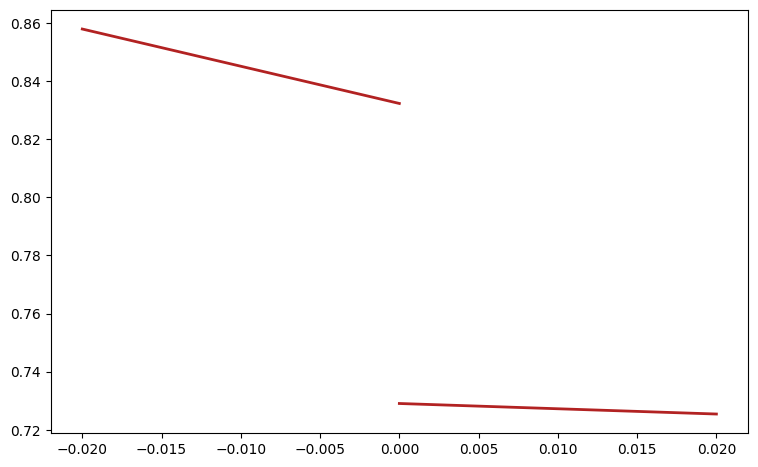

In [66]:
left = df[df["income_centered"] < 0]
right = df[df["income_centered"] >= 0]

left_coefs = np.polyfit(left["income_centered"], left["support"], deg=1)
right_coefs = np.polyfit(right["income_centered"], right["support"], deg=1)


grid_left = np.linspace(-0.02, 0, 100)
grid_right = np.linspace(0, 0.02, 100)

fig, ax = plt.subplots(figsize=(9, 5.5))
# ax.scatter(df["income_centered"], df["support"], color="steelblue", alpha=0.7, label="Binned average")
ax.plot(grid_left, np.polyval(left_coefs, grid_left), color="firebrick", linewidth=2)
ax.plot(grid_right, np.polyval(right_coefs, grid_right), color="firebrick", linewidth=2)
# ax.axvline(0, color="grey", linestyle=":", linewidth=1)

In [57]:
df['income_centered'] * df['participation']

0       0.000000
1       0.000000
2       0.000000
3       0.000000
4       0.000000
          ...   
1943   -0.013489
1944   -0.012106
1945   -0.010159
1946   -0.008668
1947   -0.003640
Length: 1897, dtype: float64

In [69]:
df['support'].value_counts()

support
1.0    1274
0.5     470
0.0     153
Name: count, dtype: int64

In [72]:
df['threshold'] = (df["income_centered"] > 0).astype(int)

formula = "support~threshold*participation+age+education+income_centered"

model = smf.ols(formula=formula, data=df).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                support   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     17.34
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           5.60e-14
Time:                        09:52:25   Log-Likelihood:                -480.76
No. Observations:                1897   AIC:                             971.5
Df Residuals:                    1892   BIC:                             999.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   0.5495      0.017     31.844      0.000       0.516       0.583
threshold                   0.2243      0.017     12.934      0.000       0.190       0.258
participation               0.3252      0.017     19.161      0.000       0.292       0.359
threshold:participation   5.26e-17   2.18e-16      0.241      0.810   -3.75e-16    4.81e-16
age                        -0.0007      0.001     -1.420      0.156      -0.002       0.000
education                  -0.0041      0.005     -0.864      0.388      -0.013       0.005
income_centered            -0.6864      1.261     -0.544      0.586      -3.160       1.788
==============================================================================
Omnibus:                      324.424   Durbin-Watson:                   1.987
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              508.096
Skew:                          -1.240   Prob(JB):                    4.66e-111
Kurtosis:                       3.524   Cond. No.                     6.56e+18
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 4.57e-32. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [50]:
df

,income_centered,education,age,participation,support
0,0.006571,3.5,23.666666,0,1.0
1,0.011075,1.5,42.000000,0,1.0
2,0.002424,4.0,43.000000,0,1.0
3,0.007650,6.0,21.000000,0,0.5
4,0.010001,2.0,33.000000,0,1.0
...,...,...,...,...,...
1943,-0.013489,2.0,27.333334,1,1.0
1944,-0.012106,4.5,37.000000,1,1.0
1945,-0.010159,5.0,25.857143,1,1.0
1946,-0.008668,3.0,26.000000,1,1.0
